In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load built-in dataset

In [2]:
# Load a built-in dataset for examples
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
flights = sns.load_dataset("flights")
iris = sns.load_dataset("iris")

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [6]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [7]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Differene between figure level function and axis level function


### Figure level function

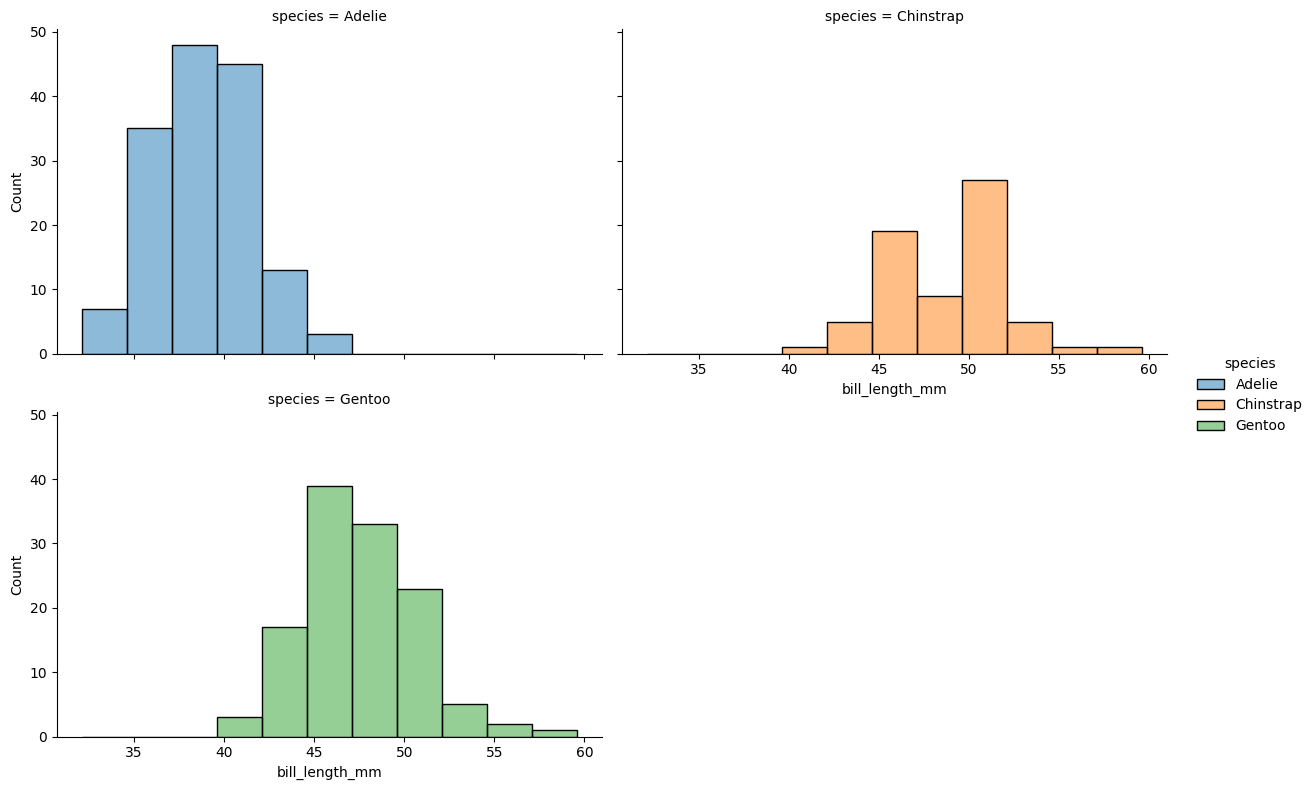

In [8]:
sns.displot(data=penguins, x="bill_length_mm", col="species",hue="species", height=4, aspect=1.5, col_wrap=2)
plt.show()

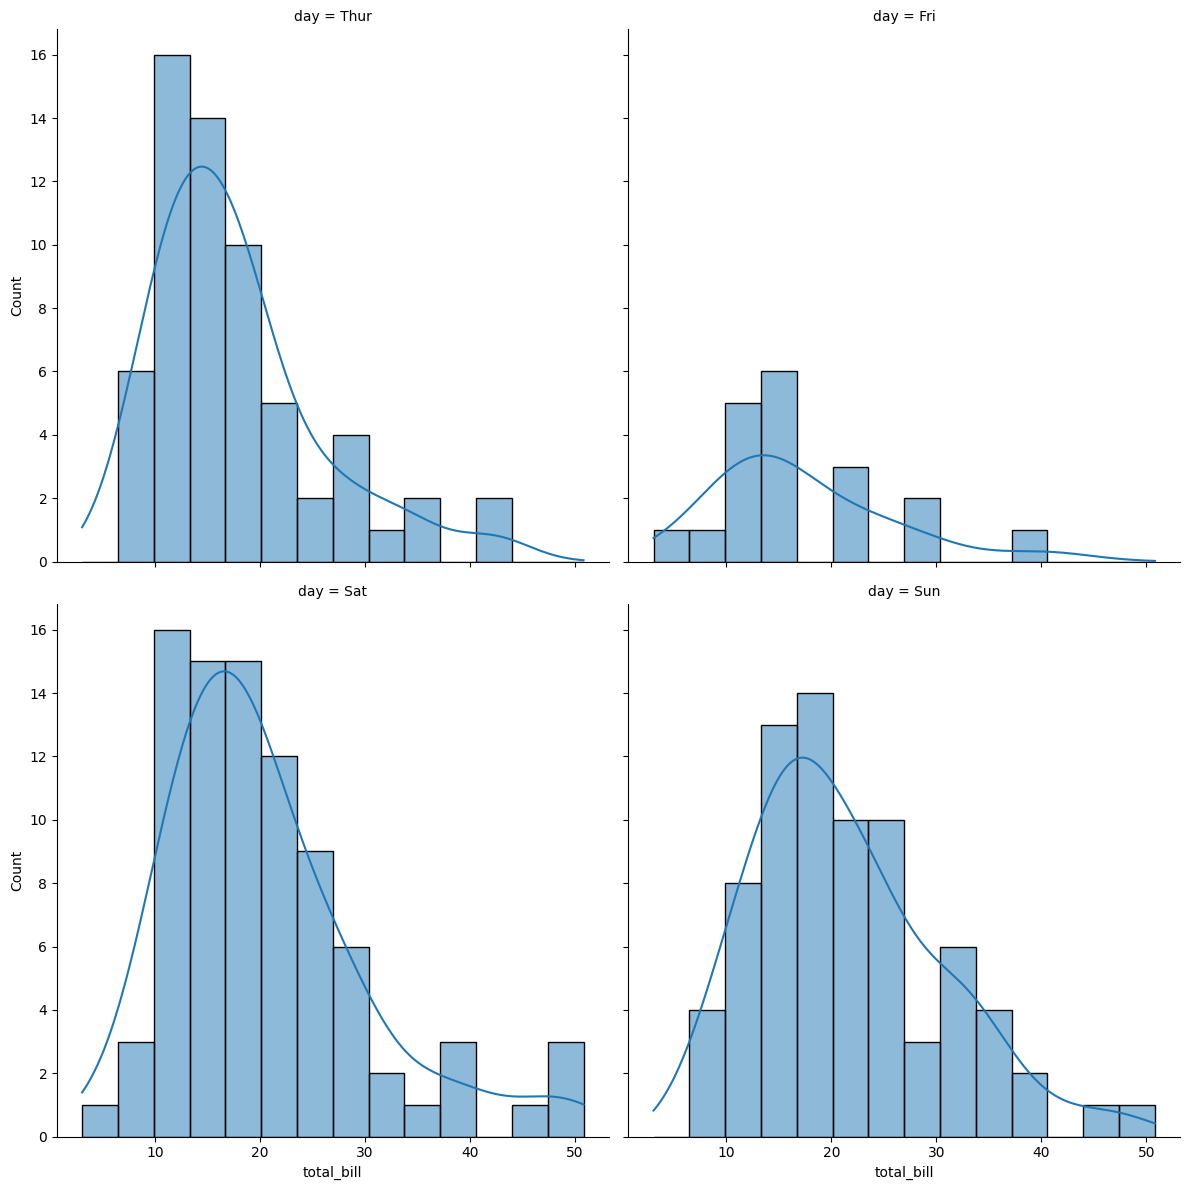

In [9]:
sns.displot(data=tips, x="total_bill",col="day", kde= True,col_wrap=2, height=6, aspect=1)
plt.show()

### Axes level function

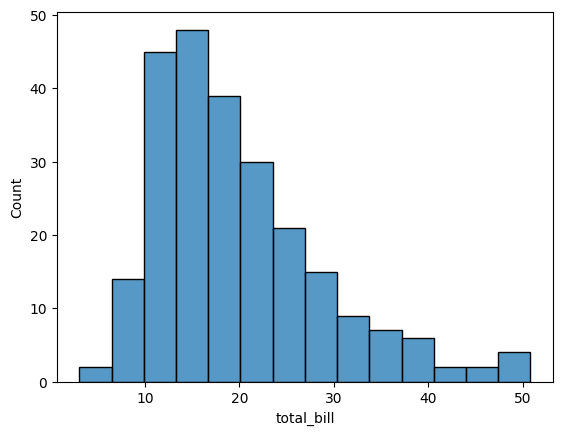

In [10]:
sns.histplot(x=tips["total_bill"])
plt.show()

### Faceting

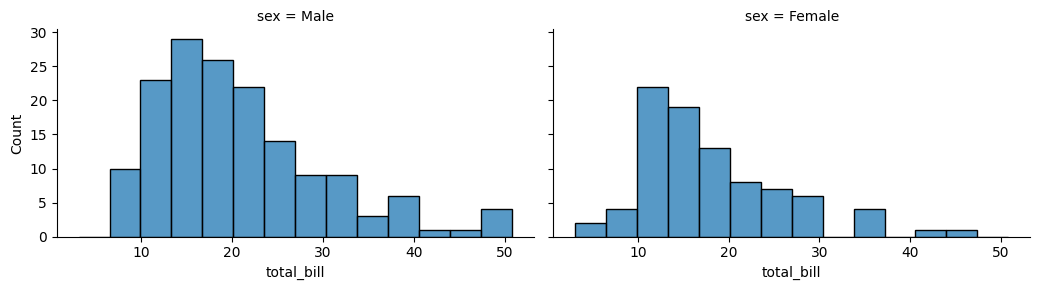

In [11]:
# Faceting in figure level function

sns.displot(kind="hist", data=tips, x="total_bill", col="sex", height=3, aspect=1.75)
plt.show()

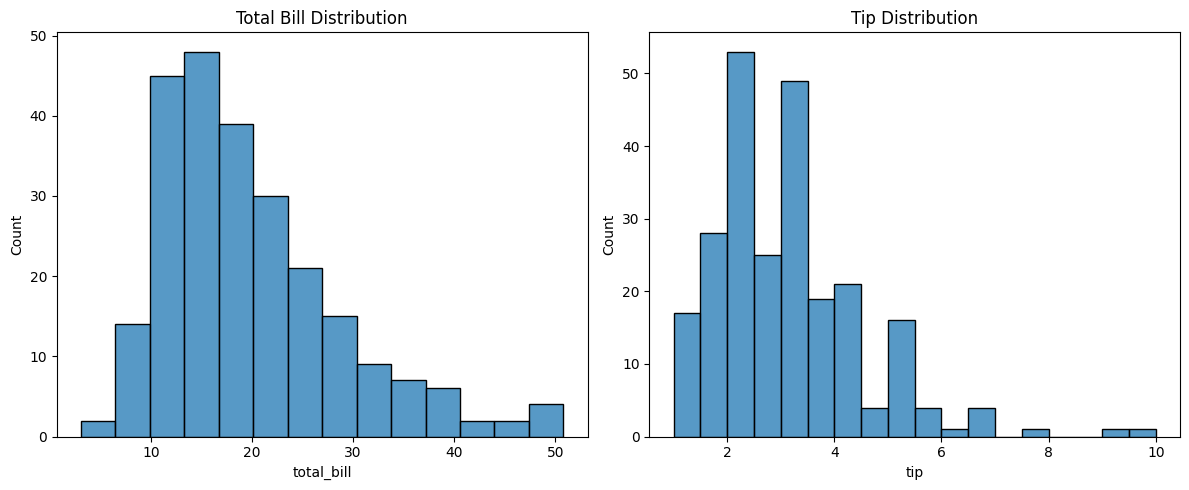

In [12]:
# Faceting in axes level function

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=tips, x="total_bill", ax=axes[0])
axes[0].set_title("Total Bill Distribution")

sns.histplot(data=tips, x="tip", ax=axes[1])
axes[1].set_title("Tip Distribution")

plt.tight_layout()
plt.show()

## Figure level functions


### displot()


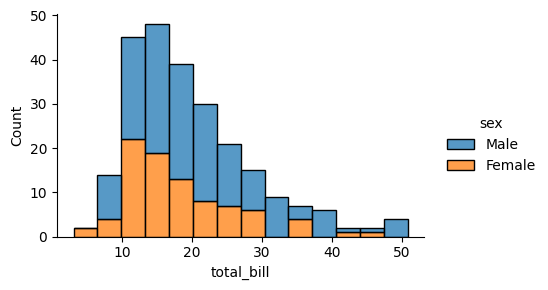

In [13]:
# Default: histogram
sns.displot(data=tips, x="total_bill", hue="sex", multiple="stack", height=3, aspect=1.5)
plt.show()

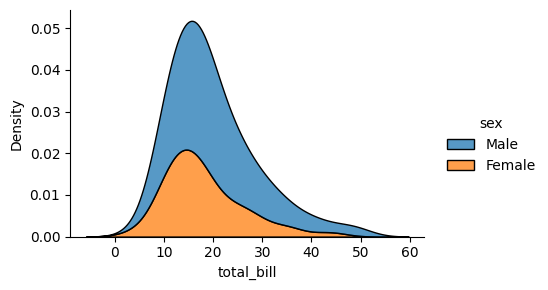

In [14]:
# KDE plot
sns.displot(data=tips, x="total_bill", kind="kde", hue="sex", fill=True, multiple="stack", height=3, aspect=1.5)
plt.show()

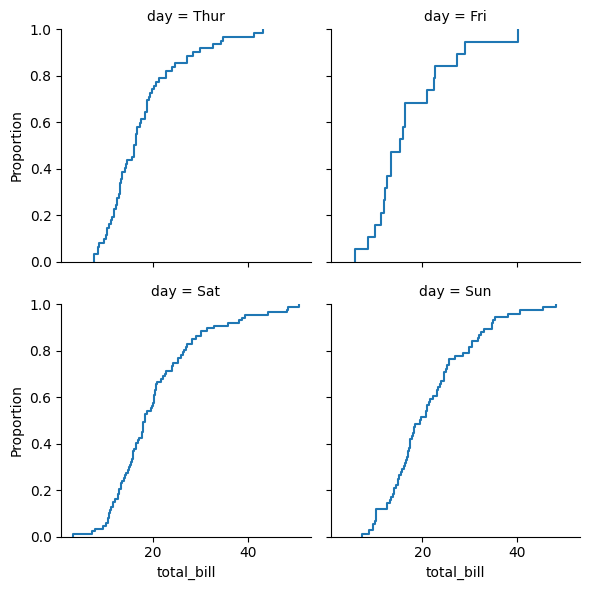

In [15]:
# ECDF plot with faceting
sns.displot(data=tips, x="total_bill", kind="ecdf", col="day", height=3, col_wrap=2)
plt.show()

### relplot()

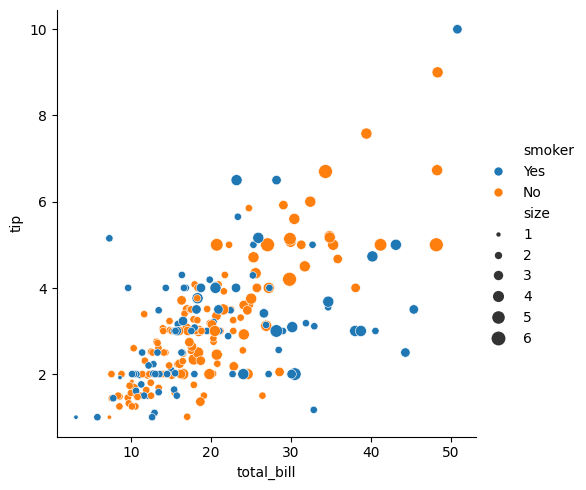

In [16]:
# Default: scatter plot
sns.relplot(data=tips, x="total_bill", y="tip", hue="smoker", size="size", sizes=(10, 100))
plt.show()

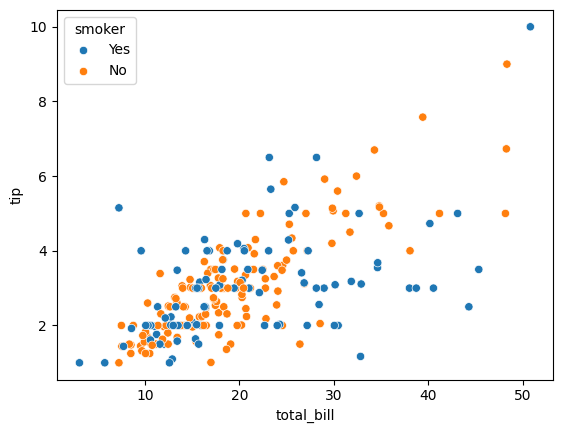

In [17]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="smoker")
plt.show()

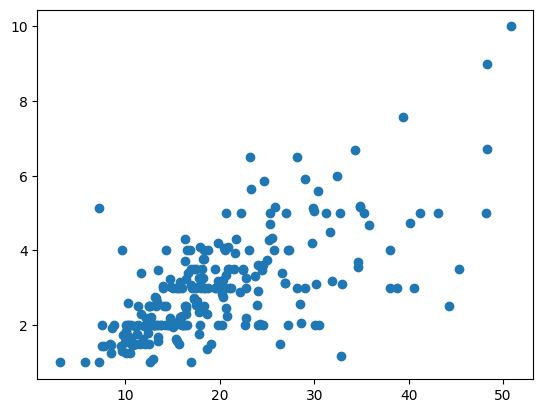

In [18]:
plt.scatter(x=tips["total_bill"], y=tips["tip"])

## Line plot()

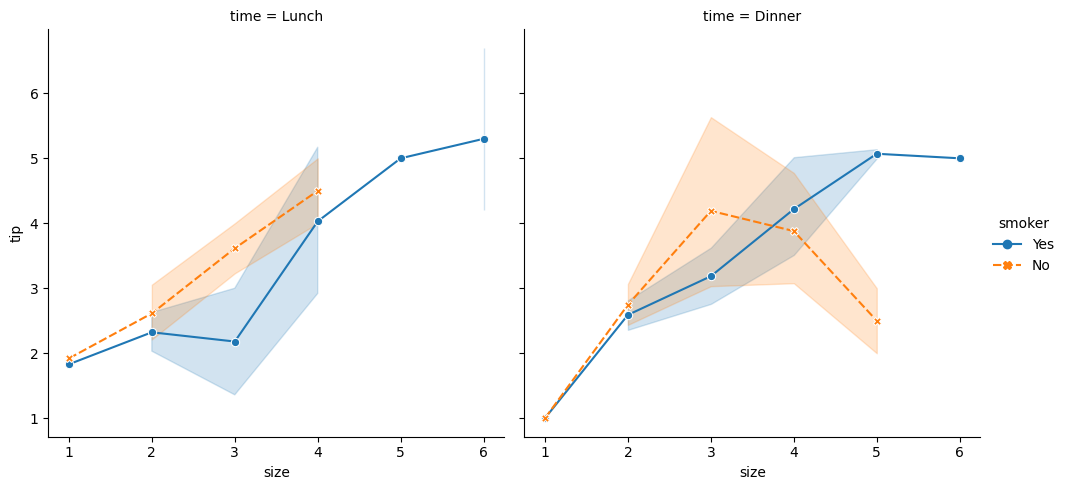

In [19]:
# Switch to line plot with kind parameter
sns.relplot(
    data=tips,
    x="size",
    y="tip",
    kind="line",
    hue="smoker",
    style="smoker",
    markers=True,
    col="time"  # facet by time (Lunch/Dinner)
)
plt.show()

## Catplot()

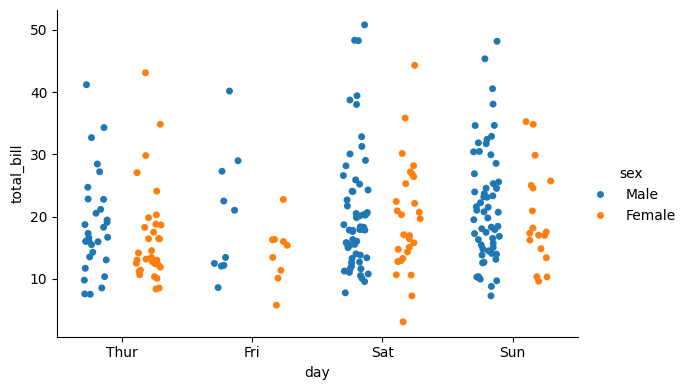

In [20]:
# Default: strip plot
sns.catplot(data=tips, x="day", y="total_bill", height=4, aspect=1.5, hue="sex", dodge=True, jitter=0.2)
plt.show()

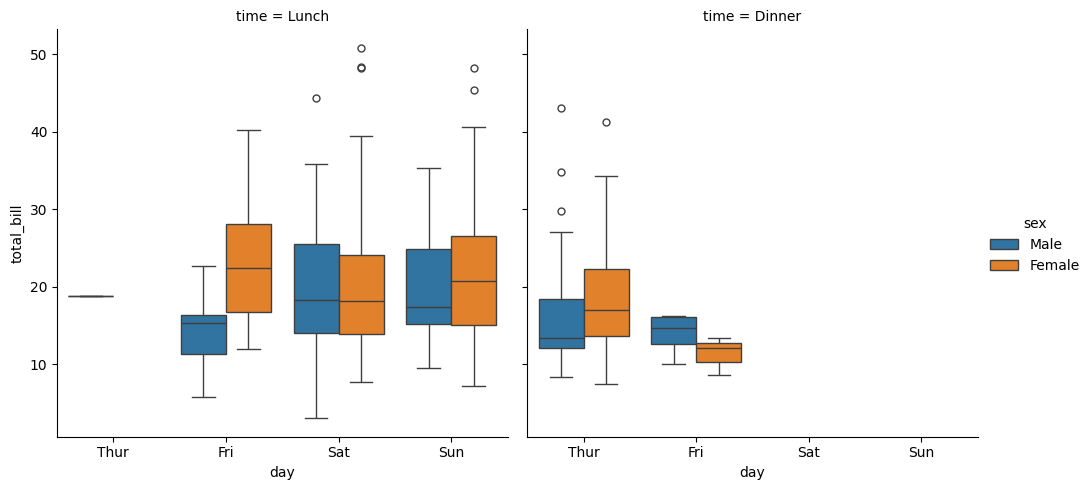

In [21]:
# Violin with faceting
sns.catplot(
    data=tips,
    x="day",
    y="total_bill",
    kind="box",
    hue="sex",
    # split=True,      # split violins by hue
    # palette="pastel",
    col="time",
    height=5
)
plt.show()

## Axes-level function

### Relational axes plot

#### Scatterplot()

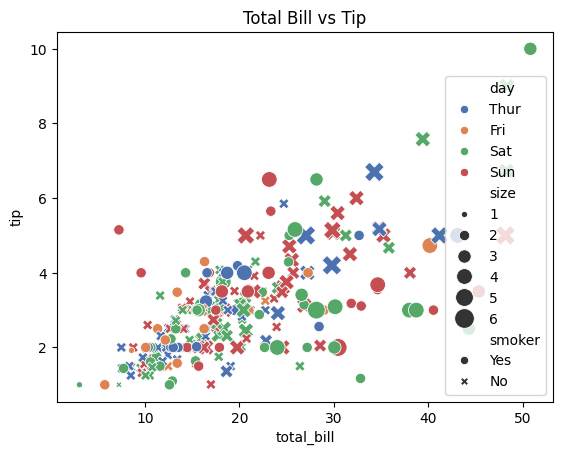

In [22]:
# With hue, size, and style
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="day",          # color by day
    size="size",       # point size by party size
    style="smoker",     # marker style by smoking status
    palette="deep",
    sizes=(20, 200)    # min and max point sizes
)
plt.title("Total Bill vs Tip")
plt.show()

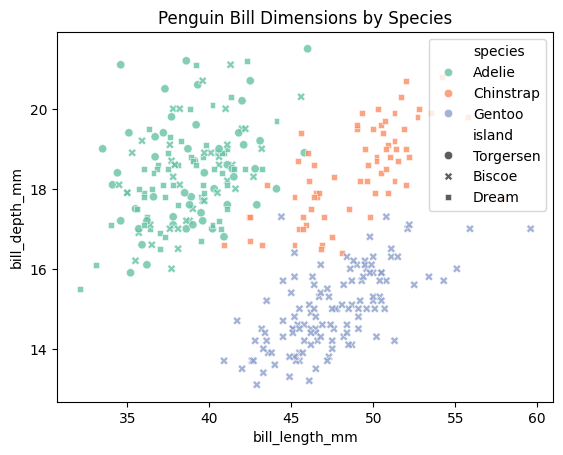

In [23]:
# Real-world: penguin bill dimensions by species
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="island",
    alpha=0.8,
    palette="Set2"
)
plt.title("Penguin Bill Dimensions by Species")
plt.show()

### Line plot()

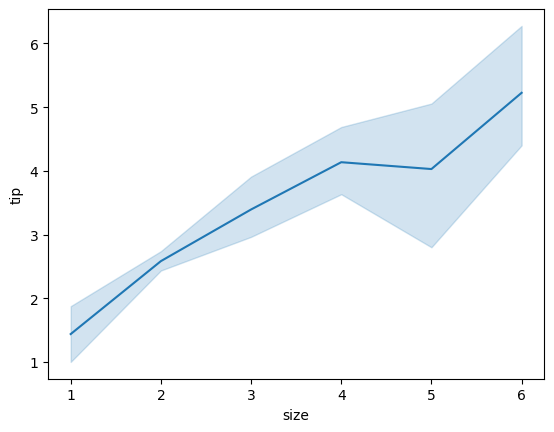

In [24]:
# Basic line plot
sns.lineplot(data=tips, x="size", y="tip")
plt.show()

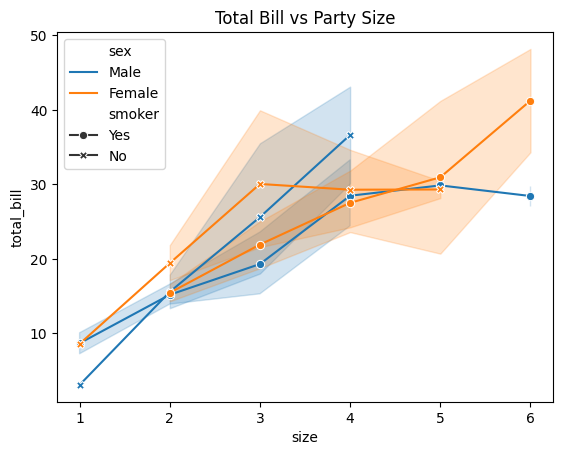

In [25]:
# With confidence interval by group
sns.lineplot(
    data=tips,
    x="size",
    y="total_bill",
    hue="sex",
    style="smoker",
    markers=True,
    dashes=False,
    errorbar="ci"       # show 95% confidence interval
)
plt.title("Total Bill vs Party Size")
plt.show()

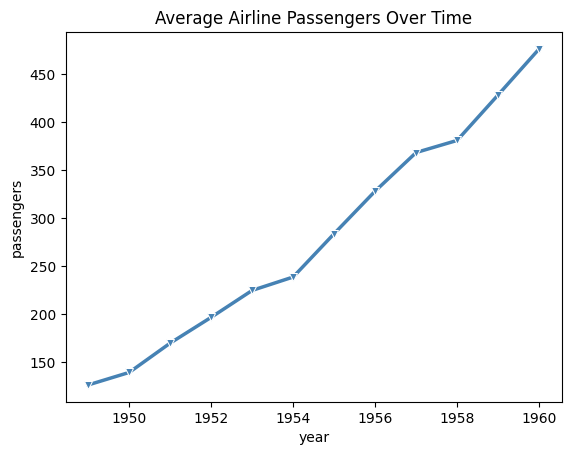

In [26]:
# Time-series style with flights dataset
flights_avg = flights.groupby("year")["passengers"].mean().reset_index()

sns.lineplot(
    data=flights_avg,
    x="year",
    y="passengers",
    marker="v",
    color="steelblue",
    linewidth=2.5
)
plt.title("Average Airline Passengers Over Time")
plt.show()

## Distribution plots Axes-level

#### One dimensional histograms

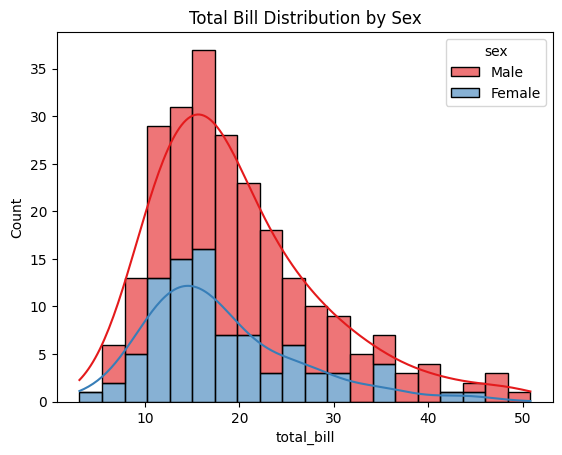

In [27]:
# Overlapping histograms with KDE
sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",
    multiple="stack",   # options: "layer", "dodge", "stack", "fill"
    kde=True,           # overlay KDE curve
    bins=20,
    palette="Set1",
    alpha=0.6
)
plt.title("Total Bill Distribution by Sex")
plt.show()

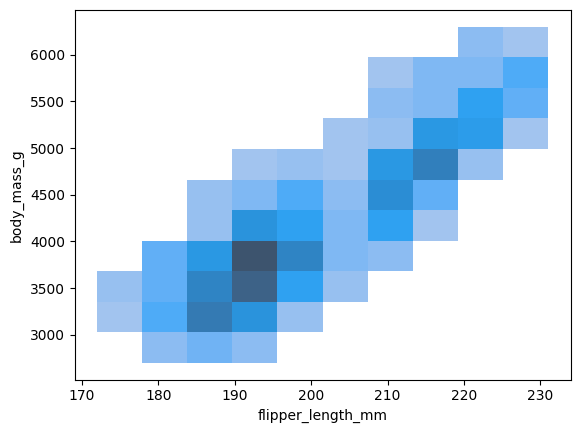

In [28]:
# 2D histogram (bivariate)
sns.histplot(data=penguins, x="flipper_length_mm", y="body_mass_g")
plt.show()

### Kdeplot()

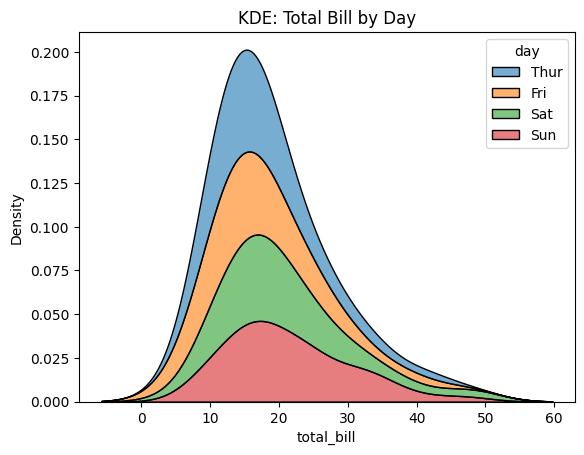

In [29]:
# Filled KDE for multiple groups
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="day",
    fill=True,
    alpha=0.6,
    palette="tab10",
    multiple="stack",
    common_norm=False    # each group normalized independently
)
plt.title("KDE: Total Bill by Day")
plt.show()

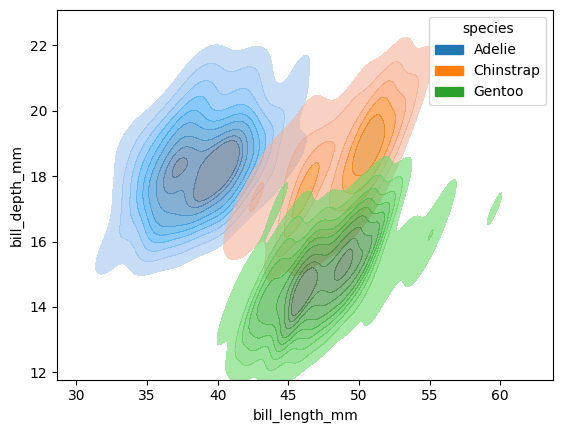

In [30]:
# 2D density contour plot
sns.kdeplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    fill=True,
    multiple="stack",
    alpha=0.6,
    thresh=0.05          # threshold for lowest contour
)
plt.show()

### ecdfplot()

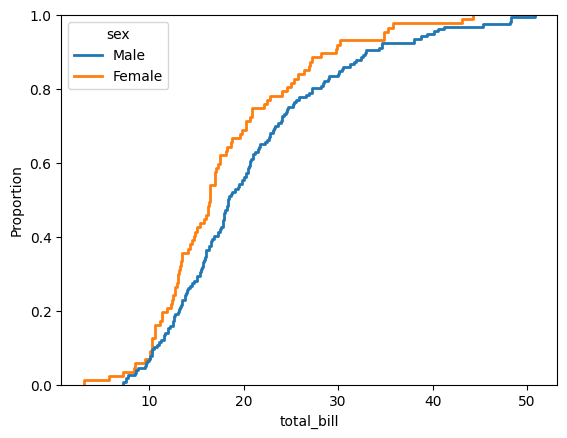

In [31]:
# Basic ECDF
sns.ecdfplot(data=tips, x="total_bill", hue="sex", linewidth= 2)
plt.show()

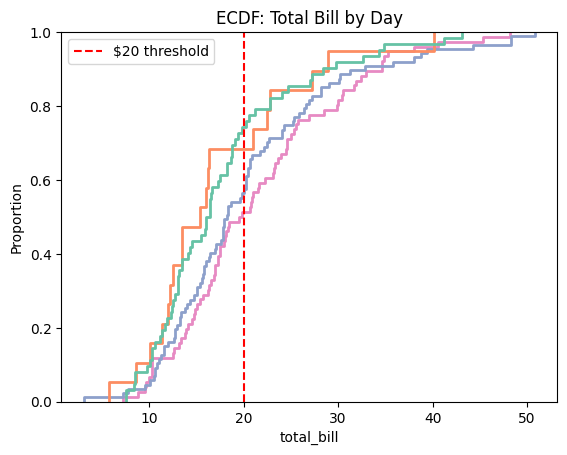

In [32]:
# Compare groups with ECDF
sns.ecdfplot(
    data=tips,
    x="total_bill",
    hue="day",
    palette="Set2",
    linewidth=2
)
plt.title("ECDF: Total Bill by Day")
plt.axvline(20, color="red", linestyle="--", label="$20 threshold")
plt.legend()
plt.show()

### Rugplot()

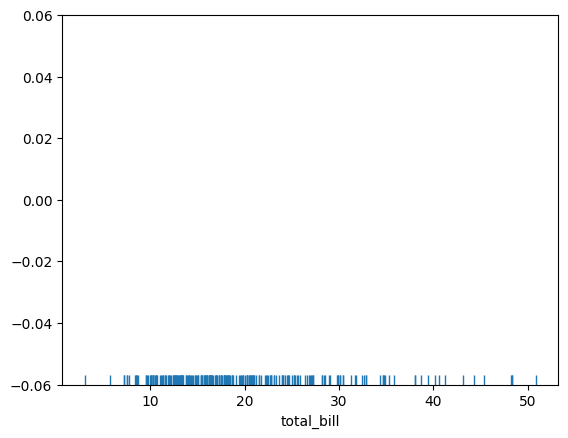

In [33]:
# Standalone rug plot
sns.rugplot(data=tips, x="total_bill")
plt.show()

#### Rug plot combined with KDE

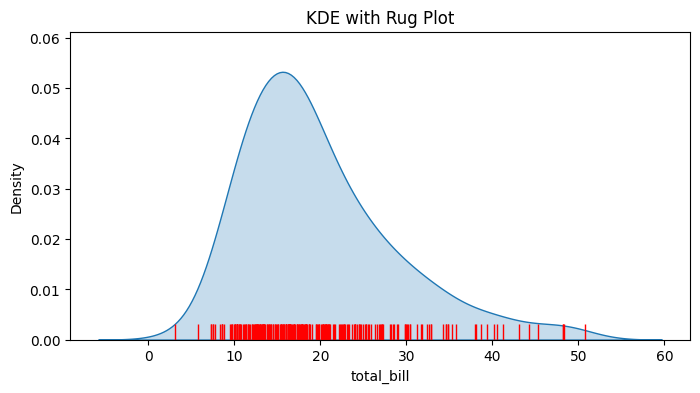

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=tips, x="total_bill", fill=True, ax=ax)
sns.rugplot(data=tips, x="total_bill", ax=ax, height=0.05, color="red")
plt.title("KDE with Rug Plot")
plt.show()

### Categorical plot

#### barplot()

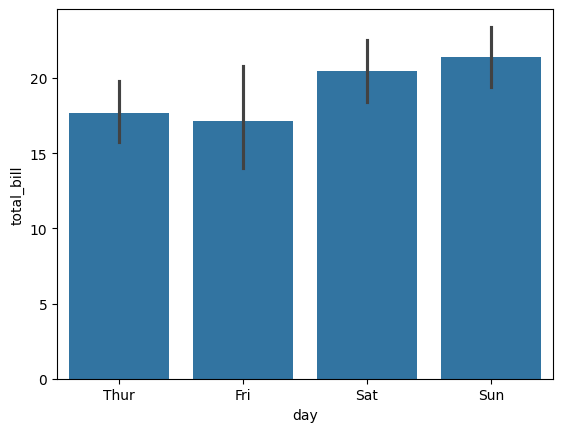

In [35]:
# Basic bar plot
sns.barplot(data=tips, x="day", y="total_bill")
plt.show()

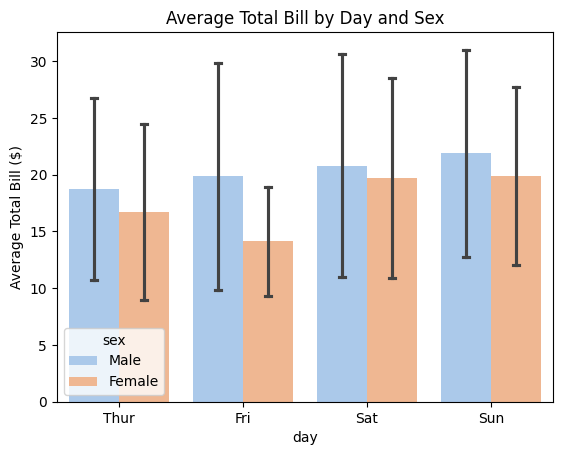

In [36]:
# Grouped bar plot with customization
sns.barplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    palette="pastel",
    errorbar="sd",         # standard deviation instead of CI
    capsize=0.1,           # add caps to error bars
    order=["Thur", "Fri", "Sat", "Sun"]
)
plt.title("Average Total Bill by Day and Sex")
plt.ylabel("Average Total Bill ($)")
plt.show()

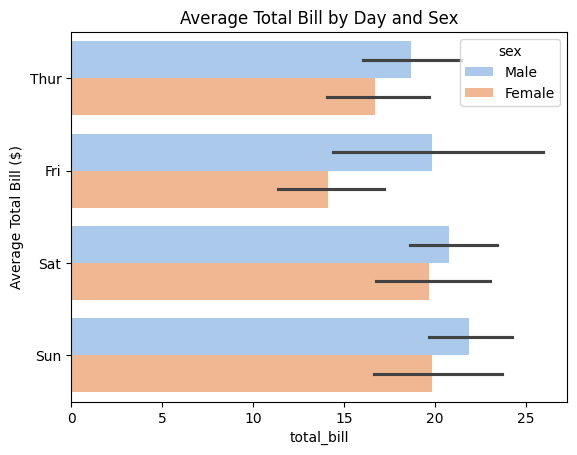

In [38]:
# Grouped bar plot with customization
sns.barplot(
    data=tips,
    y="day",
    x="total_bill",
    hue="sex",
    palette="pastel",
    orient="h"
    # errorbar="sd",         # standard deviation instead of CI
    # capsize=0.1,           # add caps to error bars
    # order=["Thur", "Fri", "Sat", "Sun"]
)
plt.title("Average Total Bill by Day and Sex")
plt.ylabel("Average Total Bill ($)")
plt.show()

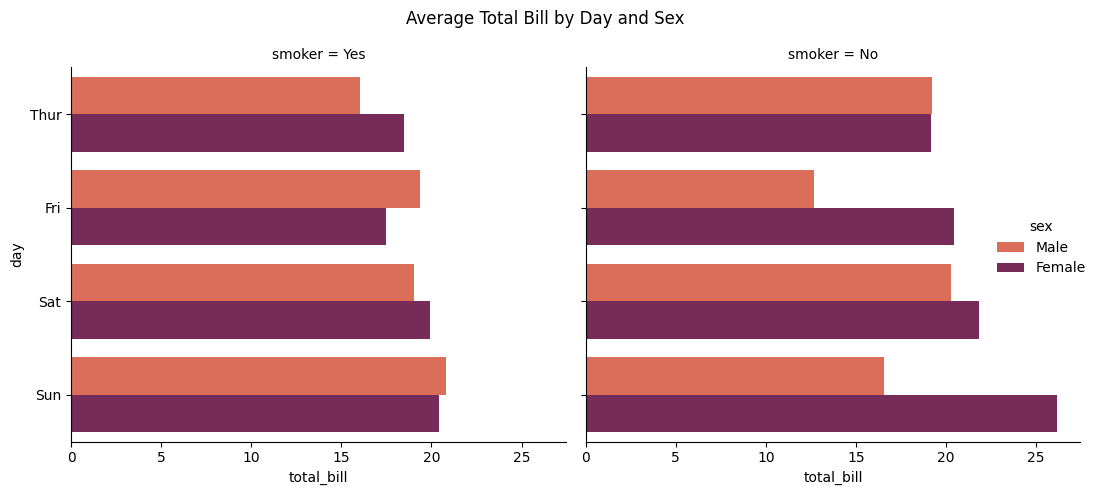

In [42]:
# Grouped bar plot with customization
sns.catplot(
    kind="bar",
    data=tips,
    y="day",
    x="total_bill",
    hue="sex",
    # palette="pastel",
    palette="rocket_r",
    col="smoker",
    orient="h",
    errorbar=None
    # height=4
    # errorbar="sd",         # standard deviation instead of CI
    # capsize=0.1,           # add caps to error bars
    # order=["Thur", "Fri", "Sat", "Sun"]
)
plt.suptitle("Average Total Bill by Day and Sex")
plt.ylabel("Average Total Bill ($)")
plt.tight_layout()
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_15916\4065483342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


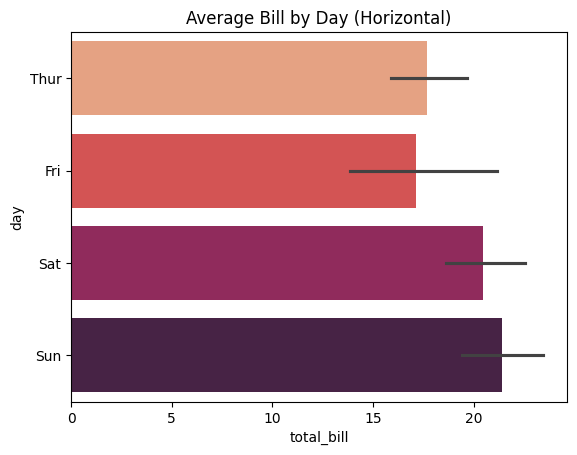

In [ ]:
# Horizontal bar plot
sns.barplot(
    data=tips,
    x="total_bill",
    y="day",
    orient="h",
    palette="rocket_r"
)
plt.title("Average Bill by Day (Horizontal)")
plt.show()

### Countplot()

<Axes: xlabel='day'>

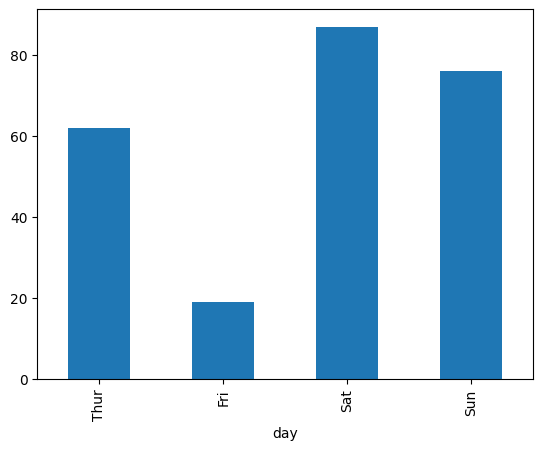

In [45]:
tips["day"].value_counts().sort_index().plot(kind="bar")

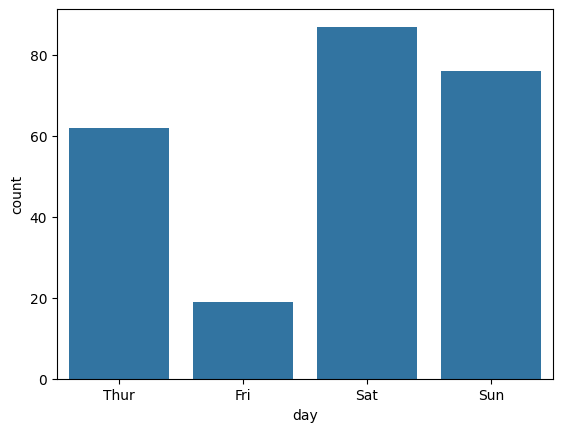

In [43]:
# Basic count plot
sns.countplot(data=tips, x="day")
plt.show()

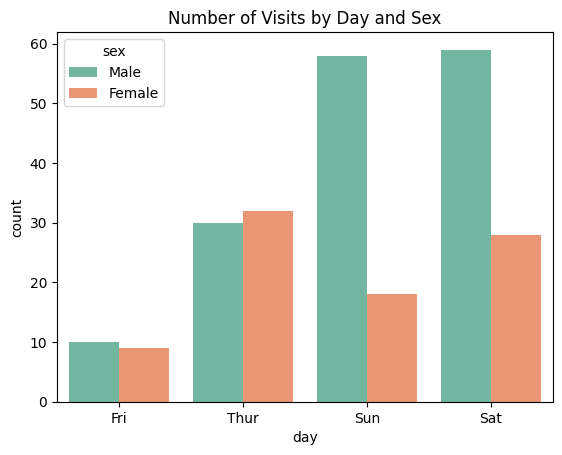

In [47]:
# Grouped count plot
sns.countplot(
    data=tips,
    x="day",
    hue="sex",
    palette="Set2",
    order=tips["day"].value_counts().sort_values(ascending=True).index   # sort by most common
)
plt.title("Number of Visits by Day and Sex")
plt.show()

#### boxplot()

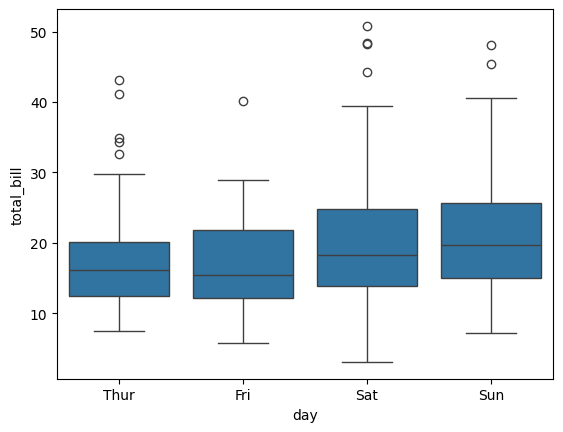

In [48]:
# Basic box plot
sns.boxplot(data=tips, x="day", y="total_bill")
plt.show()

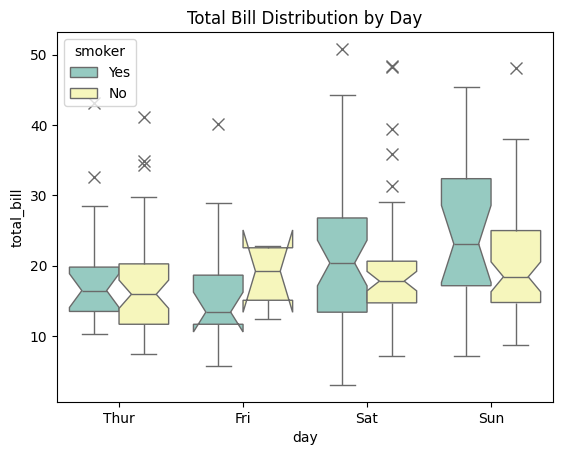

In [49]:
# Grouped box plot with customization
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="smoker",
    palette="Set3",
    notch=True,             # notch shows CI around median
    flierprops=dict(marker="x", color="red", markersize=8),  # outlier style
    order=["Thur", "Fri", "Sat", "Sun"]
)
plt.title("Total Bill Distribution by Day")
plt.show()

#### Violinplot()

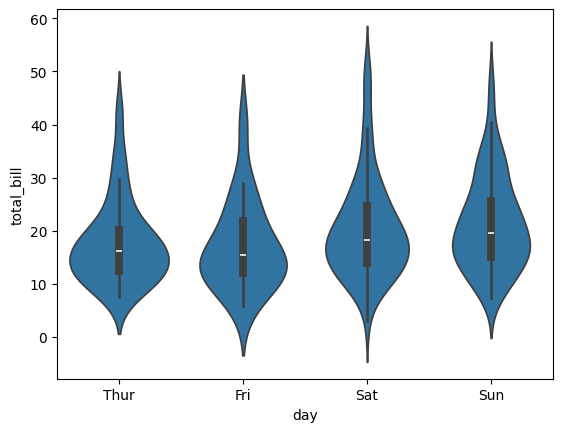

In [50]:
# Basic violin plot
sns.violinplot(data=tips, x="day", y="total_bill")
plt.show()

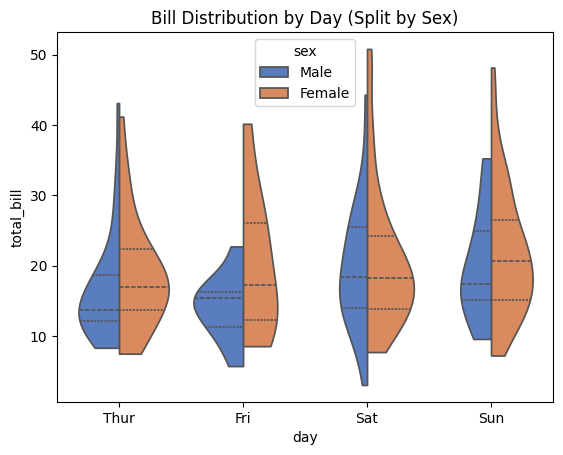

In [51]:
# Split violin with hue
sns.violinplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    split=True,            # mirror the two groups within one violin
    palette="muted",
    inner="quartile",      # show quartile lines inside violin
    cut=0                  # don't extend beyond observed data
)
plt.title("Bill Distribution by Day (Split by Sex)")
plt.show()

#### stripplot()

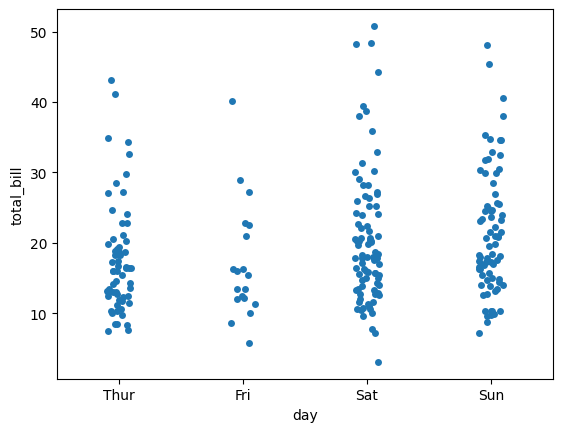

In [52]:
# Basic strip plot
sns.stripplot(data=tips, x="day", y="total_bill")
plt.show()

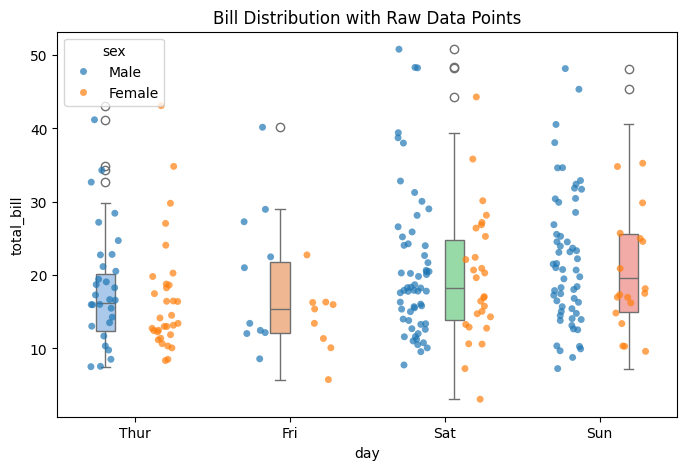

In [63]:
# Strip over box plot
fig, axes = plt.subplots(figsize=(8, 5))
sns.boxplot(data=tips, x="day", y="total_bill", palette="pastel",hue="day", ax=axes, width=0.5)
sns.stripplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    ax=axes,
    dodge=True,       # separate points by hue
    alpha=0.7,
    jitter=0.2,       # amount of horizontal jitter
    size=5
)
plt.title("Bill Distribution with Raw Data Points")
plt.show()

#### swarmplot()

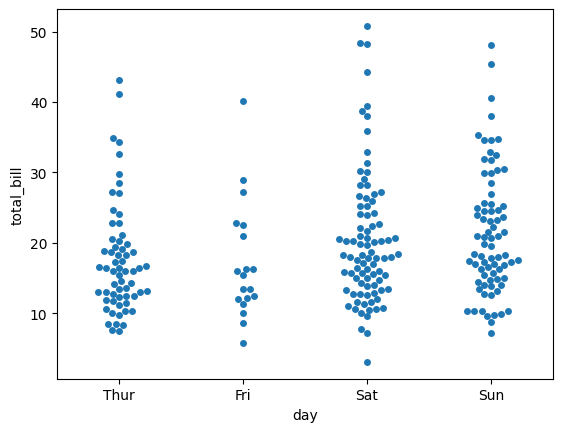

In [59]:
# Basic swarm plot
sns.swarmplot(data=tips, x="day", y="total_bill")
plt.show()

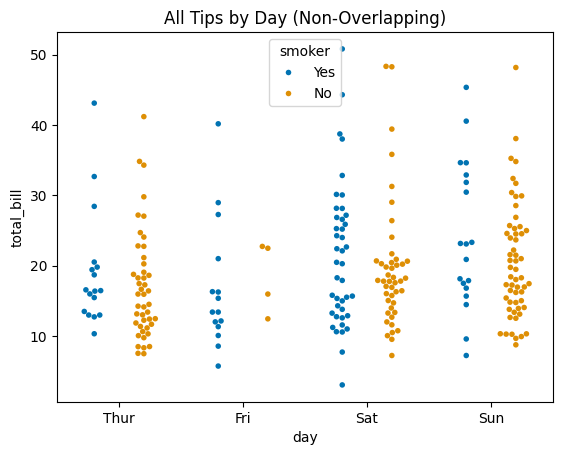

In [62]:
# Swarm with hue and size
sns.swarmplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="smoker",
    dodge=True,
    palette="colorblind",
    size=4,
    order=["Thur", "Fri", "Sat", "Sun"]
)
plt.title("All Tips by Day (Non-Overlapping)")
plt.show()

#### pointplot()

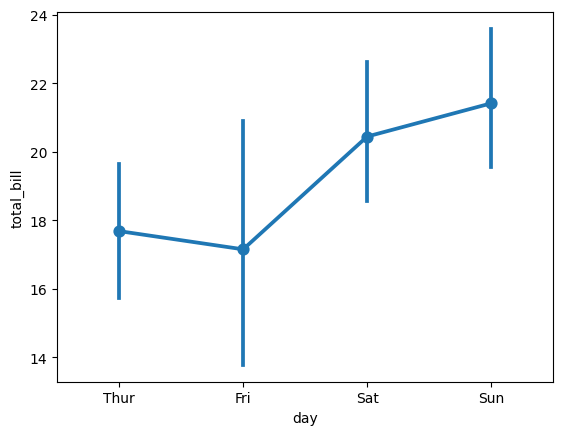

In [64]:
# Basic point plot
sns.pointplot(data=tips, x="day", y="total_bill")
plt.show()

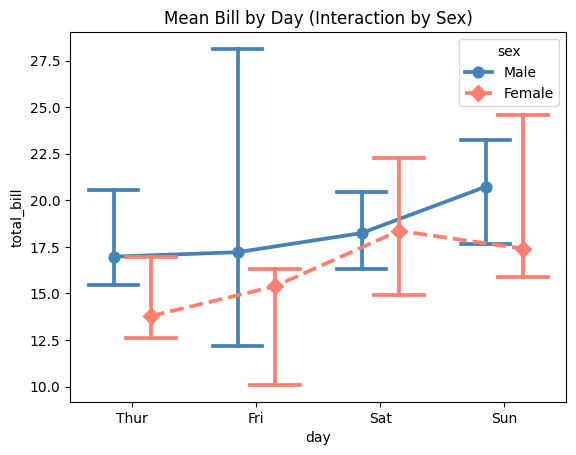

In [67]:
# Interaction plot
sns.pointplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    palette={"Male": "steelblue", "Female": "salmon"},
    markers=["o", "D"],
    linestyles=["-", "--"],
    dodge=0.3,             # separate lines horizontally
    errorbar="ci",
    capsize=0.4,
    estimator=np.median
)
plt.title("Mean Bill by Day (Interaction by Sex)")
plt.show()

#### boxenplot()

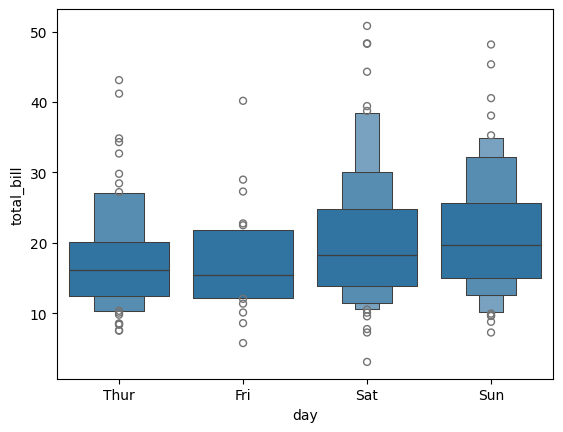

In [68]:
# Basic boxen plot
sns.boxenplot(data=tips, x="day", y="total_bill")
plt.show()

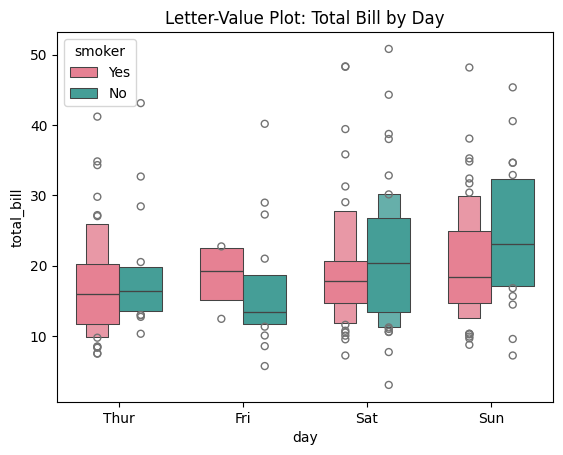

In [71]:
# Customized boxen plot
sns.boxenplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="smoker",
    palette="husl",
    k_depth="tukey",         # number of quantile levels
    outlier_prop=0.01,      # proportion treated as outliers
    width=0.7
)
plt.title("Letter-Value Plot: Total Bill by Day")
plt.show()

### Heatmap()

In [76]:
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


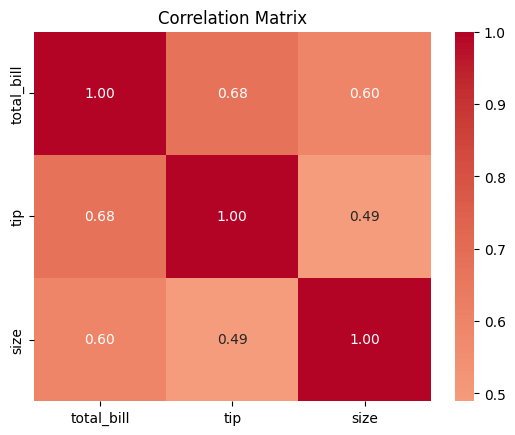

In [77]:
# Correlation heatmap
corr = tips.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

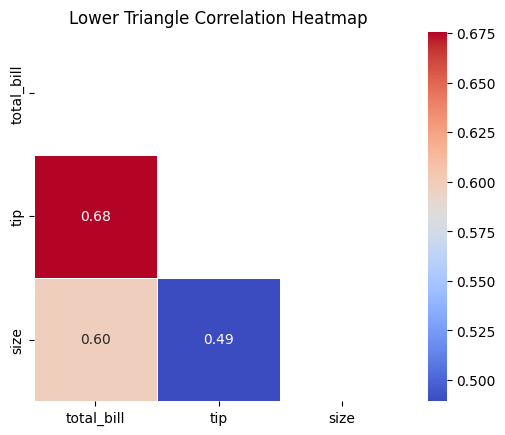

In [81]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Lower Triangle Correlation Heatmap")
plt.show()

In [80]:
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")
flights_pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


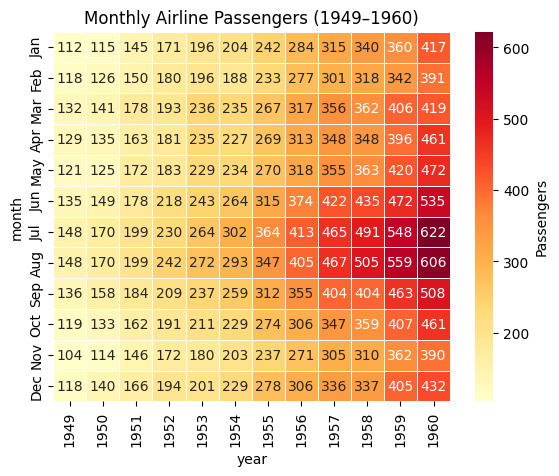

In [78]:
# Flights dataset heatmap
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

sns.heatmap(
    flights_pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Passengers"}
)
plt.title("Monthly Airline Passengers (1949–1960)")
plt.show()